<a href="https://colab.research.google.com/github/JamesTan44181/DLI-Group-Assignment/blob/main/Shao_Ern_Individual(group%20dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LTSM + ANN comparing with group dataset

# Step 1, Import library and dataset

In [1]:
import numpy as np
import pandas as pd
import time
import gdown
import glob
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

start = time.time()
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# target file
data_dir = "CIC_IDS2017"
if not os.path.exists(data_dir):
    # Download zip file of dataset for whole dataset
    file_id = "1pMMlyzmJNvURynMO0_WztdIhl6oFPASo"
    url = f"https://drive.google.com/uc?id={file_id}"
    output = "CIC-IDS2017.zip"

    # Download for only Monday-WorkingHours.csv
    #file_id = "1p9vawaAKIMof7zZY2QP-AIZEYN0k9c1u"
    #url = f"https://drive.google.com/uc?id={file_id}"
    #output = "CICIDS2017.zip"
    gdown.download(url, output, quiet=False)

    # extract
    !unzip -q CIC-IDS2017.zip -d CIC_IDS2017
else:
    print("Dataset already exists, skip downloading.")

files = glob.glob("CIC_IDS2017/MachineLearningCVE/*.csv")

sampled_dfs = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # get 40,000 in each csv
    df_sample = df.sample(n=min(40000, len(df)), random_state=42)

    sampled_dfs.append(df_sample)

# combine the data we need to used
df_combined = pd.concat(sampled_dfs, ignore_index=True)

print("Total rows after sampling:", len(df_combined))

# save
df_combined.to_csv("CICIDS2017_sampled.csv", index=False)
print("Saved to CICIDS2017_sampled.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo
From (redirected): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo&confirm=t&uuid=1c937eb9-7229-4b88-9150-2cfb988789a5
To: /content/CIC-IDS2017.zip
100%|██████████| 235M/235M [00:02<00:00, 110MB/s]


Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
Total rows after sampling: 320000
Saved to CICIDS2017_sampled.csv


In [3]:
# To combine all CSV and show the first five rows
#csv_files = glob.glob('CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.csv')
#df_list = [pd.read_csv(f) for f in csv_files]
#df = pd.concat(df_list, ignore_index=True)
#df.head()
# To get only Monday-WorkingHours dataset on CIC-IDS2017 dataset
df_combined.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,77689,4,8,6134,153,4686,0,1533.5,2209.736862,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,443,3659078,10,9,717,5821,363,0,71.7,121.708258,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,44176,76,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
3,8641,81,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,1026,61,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan


# 2. Data Preprocessing

In [4]:
# Show the total row
print("Total rows before cleaning:", len(df_combined))

# Check duplicates
print("Total duplicate rows:", df_combined.duplicated().sum())

# Delete the duplicated row
df_combined.drop_duplicates(inplace=True)
#print("Total rows after dropping duplicates:", len(df))
# The total rows after dropping duplicates is same with total rows before, so no need this process.

# Check Infinite value
numeric_df = df_combined.select_dtypes(include=[np.number])
print("Total infinite values:", np.isinf(numeric_df.values).sum())

# Process the infinite value
df_combined = df_combined.replace([np.inf, -np.inf], np.nan)

# Check missing values
#print("Total missing values:", df.isna().sum().sum())
#print("Missing values per column (if any):")
#print(df.isna().sum())

# Fill the missing value
# Since there are huge dataset, we use pandas fillna to process this.
# Pandas fillna is faster than SimpleImputer
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_combined[col].isna().sum() > 0:
       df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# Remove all the space after and before the columns name
df_combined.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm the label types
print("Unique Labels:", df_combined['Label'].unique())

# Convert the unreadable text to readable
df_combined['Label'] = df_combined['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

df_combined.to_csv("CIC_IDS2017_cleaned.csv", index=False)
print("Data cleaning complete, saved to CIC_IDS2017_cleaned.csv")
print("Total rows after cleaning:", len(df_combined))

Total rows before cleaning: 320000
Total duplicate rows: 14931
Total infinite values: 364
Unique Labels: ['BENIGN' 'PortScan' 'Infiltration' 'DDoS' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'SSH-Patator'
 'FTP-Patator' 'DoS Hulk' 'DoS Slowhttptest' 'DoS GoldenEye'
 'DoS slowloris' 'Heartbleed' 'Bot']
Data cleaning complete, saved to CIC_IDS2017_cleaned.csv
Total rows after cleaning: 305069


In [12]:
# Features and raw labels
X = df_combined.drop(columns=['Label']).values
y_raw = df_combined['Label'].values

# Train-test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("Train shape:", X_train.shape, y_train_raw.shape)
print("Test shape:", X_test.shape, y_test_raw.shape)

Train shape: (244055, 78) (244055,)
Test shape: (61014, 78) (61014,)


In [13]:
# Total the label sample
#class_counts = df_combined['Label'].value_counts()
#print("Original class distribution:")
#print(class_counts)

# Find the label types which is existed the highest time
#majority_class = class_counts.idxmax()
#print("Majority class:", majority_class)

#Separate the highest existed label and anothers
#df_majority = df_combined[df_combined['Label'] == majority_class]
#df_minority = df_combined[df_combined['Label'] != majority_class]

#Undersample the majority class to match the total of the minority class (to maintain balance).
#df_majority_downsampled = resample(df_majority,
#                                   replace=False,
#                                   n_samples=len(df_minority),
#                                   random_state=42)

#df_balanced = pd.concat([df_majority_downsampled, df_minority])
#print("Balanced class distribution:")
#print(df_balanced['Label'].value_counts())

# Convert X_train to DataFrame and add Label
df_train = pd.DataFrame(X_train, columns=df_combined.columns[:-1])
df_train['Label'] = y_train_raw

# Identify majority class and minority classes
majority_class = df_train['Label'].value_counts().idxmax()
df_majority = df_train[df_train['Label'] == majority_class]
df_minority = df_train[df_train['Label'] != majority_class]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_train_balanced = pd.concat([df_majority_downsampled, df_minority])
print("Balanced training class distribution:")
print(df_train_balanced['Label'].value_counts())

# Separate features and labels
X_train_bal = df_train_balanced.drop('Label', axis=1).values
y_train_bal_raw = df_train_balanced['Label'].values

Balanced training class distribution:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


In [14]:
# Print out all the column name
#print(df.columns.tolist())

# Remove all the space after and before the columns name
#df.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm again the columns name
#print(df.columns.tolist())

# Confirm the label types
#print("Unique Labels:", df['Label'].unique())

# Convert the unreadable text to readable
#df['Label'] = df['Label'].replace({
#    'Web Attack � Brute Force': 'Web Attack - Brute Force',
#    'Web Attack � XSS': 'Web Attack - XSS',
#    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
#})
# Above put in data cleaning places

ohe = OneHotEncoder(sparse_output=False)
labels = ohe.fit_transform(df_balanced[['Label']])
print("First 5 one-hot encoded labels:")
print(labels[:5])
print("Classes:", ohe.categories_)

First 5 one-hot encoded labels:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Classes: [array(['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
       'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed',
       'Infiltration', 'PortScan', 'SSH-Patator',
       'Web Attack - Brute Force', 'Web Attack - Sql Injection',
       'Web Attack - XSS'], dtype=object)]


In [15]:
feature_names = df_balanced.drop(columns=['Label']).columns.tolist()
print("\nNumber of features:", len(feature_names))
print("Feature names (前10个示例):", feature_names[:10])

class_counts = df_balanced['Label'].value_counts()
print("\nClass distribution table:")
print(class_counts)


Number of features: 78
Feature names (前10个示例): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Class distribution table:
Label
BENIGN                        55883
DDoS                          22808
PortScan                      19680
DoS Hulk                      10285
FTP-Patator                     600
DoS GoldenEye                   565
Bot                             385
SSH-Patator                     378
Web Attack - Brute Force        364
DoS slowloris                   325
DoS Slowhttptest                318
Web Attack - XSS                164
Web Attack - Sql Injection        5
Infiltration                      4
Heartbleed                        2
Name: count, dtype: int64


In [16]:
# Except label, all is features
features = df_balanced.drop(columns=['Label'])
labels = ohe.fit_transform(df_balanced[['Label']])

# Standardize scaler
scaler = StandardScaler()

# Do scaling for all features
features_scaled = scaler.fit_transform(features)

print("Shape of features:", features_scaled.shape)
print("Shape of labels:", labels.shape)

#print("Done in:", time.time() - start, "seconds")

Shape of features: (111766, 78)
Shape of labels: (111766, 15)


In [17]:
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

In [18]:
# --- Imports ---
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# --- 1) Train/Val/Test Split ---
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)

X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train_raw,
    test_size=0.2,
    stratify=y_train_raw,
    random_state=42
)

## 3. LSTM-ANN


In [19]:
from sklearn.model_selection import train_test_split
SEED = 42

# --- 2) One-Hot Encode Labels ---
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
y_tr  = enc.fit_transform(y_tr_raw.reshape(-1,1))
y_val = enc.transform(y_val_raw.reshape(-1,1))
y_test = enc.transform(y_test_raw.reshape(-1,1))

num_classes = y_tr.shape[1]   # should be 15
print("Classes:", enc.categories_[0].tolist())

# --- 3) Reshape Features for LSTM ---
X_tr_3d  = X_tr.reshape(X_tr.shape[0],  X_tr.shape[1],  1)
X_val_3d = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_te_3d  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


In [20]:
## Reshape features for LSTM (samples, timesteps=n_features, channels=1)
import numpy as np

assert X_train.ndim == 2 and X_test.ndim == 2, "X must be 2D before reshaping"
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

X_train_lstm.shape, X_test_lstm.shape

((244055, 78, 1), (61014, 78, 1))

In [24]:
## Model: ANN + LSTM hybrid for binary classification
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

SEED = 42
tf.random.set_seed(SEED)

# --- 4) Define LSTM Model ---
model = Sequential([
    LSTM(64, input_shape=(X_tr_3d.shape[1], 1), return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')   # multiclass output
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,287 (87.06 KB)

 Trainable params: 22,159 (86.56 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
num_classes = y_train.shape[1]  # 15

model = tf.keras.Sequential([
    LSTM(32, input_shape=(X_train_lstm.shape[1], 1), return_sequences=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Train model

In [ ]:
# --- 5) Callbacks ---
earlystop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# --- 6) Train ---
history = model.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=10, batch_size=64,
    callbacks=[earlystop, reducelr],
    verbose=1
)

Epoch 1/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 143s 46ms/step - accuracy: 0.9123 - loss: 0.3359 - val_accuracy: 0.9857 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 2/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 132s 43ms/step - accuracy: 0.9825 - loss: 0.0791 - val_accuracy: 0.9819 - val_loss: 0.0676 - learning_rate: 0.0010
Epoch 3/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 149s 45ms/step - accuracy: 0.9831 - loss: 0.0734 - val_accuracy: 0.9880 - val_loss: 0.0440 - learning_rate: 0.0010
Epoch 4/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 140s 46ms/step - accuracy: 0.9844 - loss: 0.0629 - val_accuracy: 0.9824 - val_loss: 0.0567 - learning_rate: 0.0010
Epoch 5/10
2812/3051 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9867 - loss: 0.0546

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# One-hot labels → class indices
if y_test_np.ndim == 2 and y_test_np.shape[1] > 1:
    y_true_cls = y_test_np.argmax(axis=1)
else:
    y_true_cls = y_test_np.astype(int)

# Softmax probabilities → predicted class index
y_pred_cls = y_proba.argmax(axis=1)

print("Classification report:\n", classification_report(y_true_cls, y_pred_cls, digits=4))
cm = confusion_matrix(y_true_cls, y_pred_cls)
print("Confusion matrix:\n", cm)

# Multiclass AUC (one-vs-rest) requires one-hot y_true:
try:
    if y_test_np.ndim == 1:
        # make one-hot from class indices
        num_classes = y_proba.shape[1]
        y_true_1h = np.eye(num_classes)[y_true_cls]
    else:
        y_true_1h = y_test_np
    auc_ovr = roc_auc_score(y_true_1h, y_proba, multi_class='ovr')
    print("ROC-AUC (OvR):", f"{auc_ovr:.4f}")
except Exception as e:
    print("ROC-AUC not available:", e)


Classification report:
               precision    recall  f1-score   support

           0     0.9719    0.9547    0.9633     11177
           1     0.0000    0.0000    0.0000        77
           2     0.9905    0.9792    0.9848      4562
           3     0.8609    0.8761    0.8684       113
           4     0.9096    0.9927    0.9493      2057
           5     0.9024    0.5873    0.7115        63
           6     0.8000    0.8615    0.8296        65
           7     0.8889    1.0000    0.9412       120
           9     0.0000    0.0000    0.0000         1
          10     0.9389    0.9959    0.9666      3936
          11     0.7200    0.7105    0.7152        76
          12     0.0000    0.0000    0.0000        73
          13     0.0000    0.0000    0.0000         1
          14     0.0000    0.0000    0.0000        33

    accuracy                         0.9603     22354
   macro avg     0.5702    0.5684    0.5664     22354
weighted avg     0.9536    0.9603    0.9564     22354

C

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## 8. Evaluation: Accuracy, Precision, Recall, F1-score, ROC–AUC

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc = accuracy_score(y_true_cls, y_pred_cls)
prec, rec, f1, _ = precision_recall_fscore_support(y_true_cls, y_pred_cls, average='macro', zero_division=0)

print("📊=============== Core Performance Metrics (Macro) ===============📊")
print("Accuracy: ", f"{acc:.4f}")
print("Precision:", f"{prec:.4f}")
print("Recall:   ", f"{rec:.4f}")
print("F1-score: ", f"{f1:.4f}")

📊=============== Core Performance Metrics (Macro) ===============📊
Accuracy:  0.9603
Precision: 0.5702
Recall:    0.5684
F1-score:  0.5664


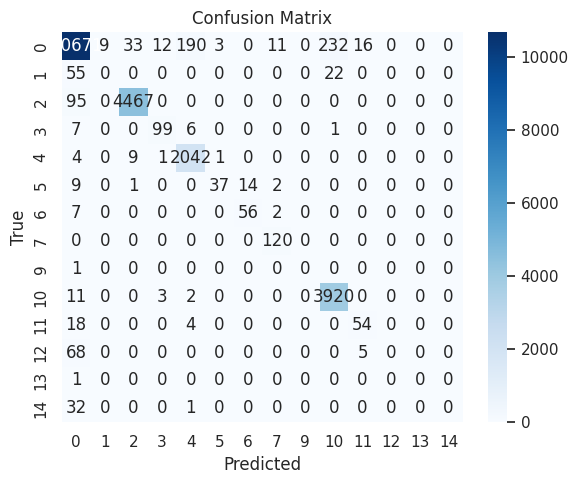

📊 Core Metrics (Macro-Averaged for Multiclass)
Accuracy:  0.9603
Precision: 0.5702
Recall:    0.5684
F1-score:  0.5664


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Inputs assumed available:
# y_test        # could be Series/ndarray, 1D or one-hot (N,K)
# y_proba       # model.predict(...) -> (N,1) for binary sigmoid, or (N,K) for softmax
# (If you already have y_pred as class IDs, you can skip to the "Sanity checks" section.)

# 1) Coerce y_test to numpy
y_true_np = y_test.to_numpy() if isinstance(y_test, (pd.Series, pd.DataFrame)) else np.asarray(y_test)
y_proba_np = np.asarray(y_proba)

# 2) Decide binary vs multiclass from y_proba shape
MULTICLASS = (y_proba_np.ndim == 2 and y_proba_np.shape[1] > 1)

if MULTICLASS:
    # Multiclass: use argmax on both sides to get class indices
    y_pred = y_proba_np.argmax(axis=1)
    y_true = y_true_np.argmax(axis=1) if (y_true_np.ndim == 2 and y_true_np.shape[1] > 1) else y_true_np.astype(int)
else:
    # Binary: threshold probabilities at 0.5
    y_pred = (y_proba_np.ravel() >= 0.5).astype(int)
    # If y_true is one-hot, collapse to binary; assume column 0 is BENIGN -> adjust if different
    if y_true_np.ndim == 2 and y_true_np.shape[1] > 1:
        BENIGN_COL_IDX = 0   # <-- change if your BENIGN column is elsewhere
        y_true = (y_true_np.argmax(axis=1) != BENIGN_COL_IDX).astype(int)  # benign=0, attack=1
    else:
        y_true = y_true_np.astype(int)

# 3) Sanity checks
assert len(y_true) == len(y_pred), f"Length mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}"
if MULTICLASS:
    classes = np.unique(np.concatenate([y_true, y_pred]))
else:
    classes = np.array([0,1])

# 4) Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

plt.figure(figsize=(6,5))
sns.set(font_scale=1.0)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 5) Optional: print metrics that match your case
if MULTICLASS:
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print("📊 Core Metrics (Macro-Averaged for Multiclass)")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
else:
    from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
    # If you still have y_proba_np from the binary branch:
    y_proba_1d = y_proba_np.ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba_1d)
    print("📊 Core Performance Metrics (Binary)")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
